# Q-TRACE — End-to-End Demo

This notebook walks through the full Q-TRACE pipeline: generating the QKD-TRACE benchmark dataset, training every classical/quantum baseline plus the composite Q-TRACE detector, and producing the comparison table and figures.

**Run this from the repository root** with the `qgss` environment active:
```
conda activate qgss
jupyter notebook
```
then open this notebook.

> For a real research run, increase `runs_per_class` / `windows_per_run` substantially (see the terminal commands in `README.md`). This notebook uses small values so it completes in a couple of minutes for demonstration.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## 1. Sanity-check the QKD Digital Twin

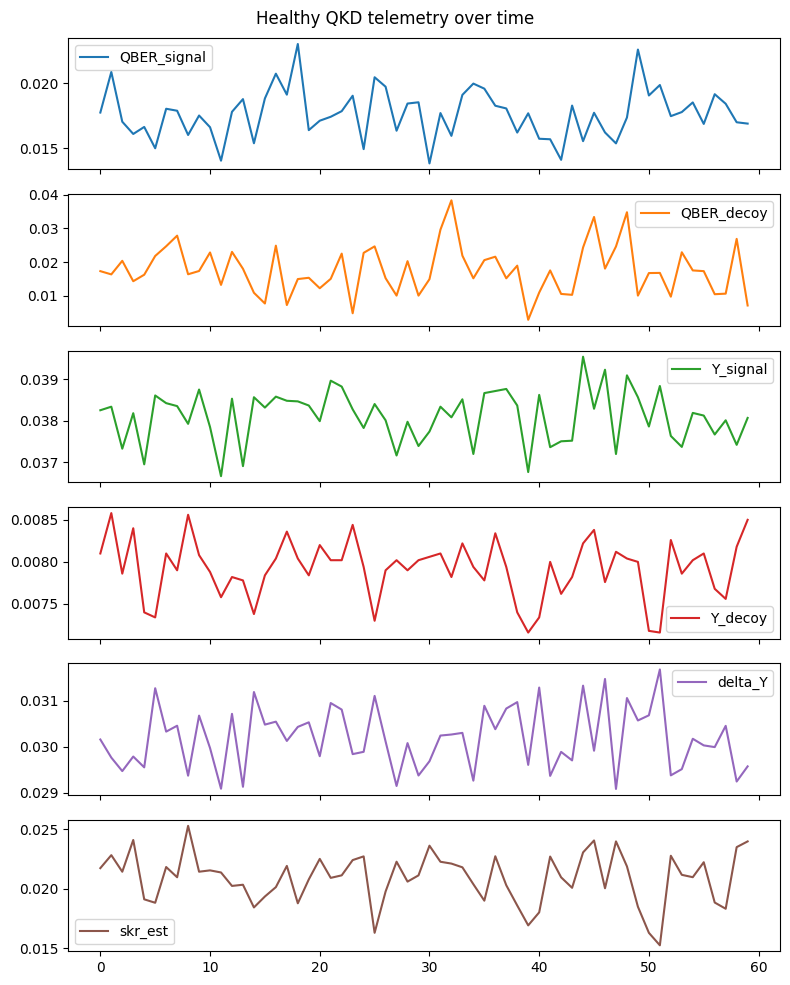

In [2]:
from qkd_simulator.bb84 import DecoyBB84Simulator

sim = DecoyBB84Simulator()
df_demo = sim.simulate_run(n_windows=60, run_id='demo0')
df_demo[['QBER_signal','QBER_decoy','Y_signal','Y_decoy','delta_Y','skr_est']].plot(
    subplots=True, figsize=(8,10), title='Healthy QKD telemetry over time')
plt.tight_layout()
plt.show()

## 2. Visualize an attack signature (PNS)

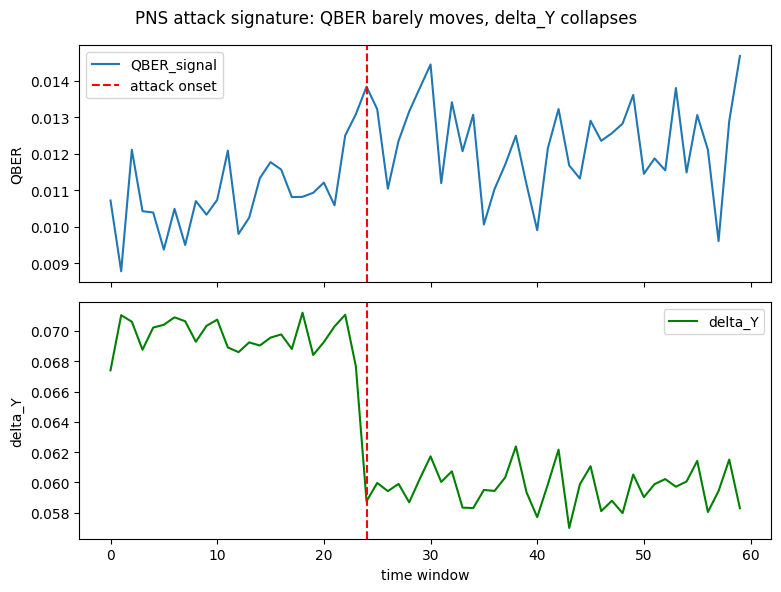

In [3]:
from attacks import make_attack

rng = np.random.default_rng(1)
atk = make_attack('pns', onset_frac=0.4, strength=1.0, rng=rng)
df_atk = sim.simulate_run(n_windows=60, attack=atk, run_id='demo_pns', attack_family='pns')

fig, axes = plt.subplots(2, 1, figsize=(8,6), sharex=True)
axes[0].plot(df_atk.t, df_atk.QBER_signal, label='QBER_signal')
axes[0].axvline(24, color='red', linestyle='--', label='attack onset')
axes[0].set_ylabel('QBER'); axes[0].legend()
axes[1].plot(df_atk.t, df_atk.delta_Y, label='delta_Y', color='green')
axes[1].axvline(24, color='red', linestyle='--')
axes[1].set_ylabel('delta_Y'); axes[1].set_xlabel('time window'); axes[1].legend()
fig.suptitle('PNS attack signature: QBER barely moves, delta_Y collapses')
plt.tight_layout()
plt.show()

## 3. Generate the benchmark dataset (small demo scale)

In [4]:
!cd .. && python -m dataset.generate --out dataset/qkd_trace_demo --runs-per-class 3 --windows-per-run 40 --block-size 15 --seed 42

[1/5] Generating TRAIN split (known attacks, nominal regime)...


[2/5] Generating VALIDATION split (known attacks, nominal regime)...
[3/5] Generating ZERO-DAY TEST split (unseen attack families, nominal regime)...
[4/5] Generating PHYSICAL-SHIFT TEST split (known attacks, shifted regime)...


[5/5] Generating COMPOSITIONAL ZERO-DAY TEST split...


Saved flat telemetry table -> dataset/qkd_trace_demo/qkd_trace_telemetry.csv  (3880 rows, 97 runs)
Building temporal blocks (this may take a moment)...


Saved temporal blocks -> dataset/qkd_trace_demo/qkd_trace_temporal_blocks.npz

=== Dataset summary (rows per split x attack_family) ===
attack_family        blinding  ...  trojan_horse+time_shift
split                          ...                         
test_composite              0  ...                      200
test_physical_shift       200  ...                        0
test_zeroday                0  ...                        0
train                     120  ...                        0
val                       200  ...                        0

[5 rows x 11 columns]


## 4. Run the full experiment suite

In [5]:
!cd .. && python -m evaluation.run_experiments --data dataset/qkd_trace_demo/qkd_trace_telemetry.csv --block-size 15 --n-qubits 4 --out results_demo --smoke

[data] train=(480, 15, 18) val=(800, 15, 18) zeroday=(800, 15, 18) shift=(800, 15, 18) composite=(1000, 15, 18)
[models] fitting classical supervised baselines...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


[models] fitting unsupervised anomaly baselines...


[models] fitting quantum kernel + VQC...


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(



=== Comparison table (all splits) ===
         split              model    AUROC    AUPRC       F1   FAR
   known (val)            XGBoost 0.588500 0.836404 0.754098 0.825
   known (val)       RandomForest 0.423433 0.715020 0.824439 0.800
   known (val) LogisticRegression 0.552567 0.830695 0.687329 0.800
   known (val)                SVM 0.533333 0.834975 0.666667 1.000
   known (val)               LSTM 0.486167 0.819931 0.857143 1.000
   known (val)                GRU 0.486167 0.819931 0.857143 1.000
   known (val)        TemporalCNN 0.486167 0.819931 0.857143 1.000
   known (val)    IsolationForest 0.774083 0.919302 0.764368 0.840
   known (val)        OneClassSVM 0.786667 0.929784 0.235294 0.600
   known (val)        Autoencoder 0.672142 0.873915 0.268398 0.800
   known (val)      QuantumKernel 0.593750 0.861572 0.888889 1.000
   known (val)                VQC      NaN 0.000000 0.000000   NaN
   known (val)            Q-TRACE 0.582225 0.850191 0.260870 0.995
      zero_day         


[SKRR] computing secret-key retention under Q-TRACE gating...


{'Q-TRACE': 0.9032944787754267, 'Static QBER Threshold': 1.0, 'No Detection (baseline)': 1.0}

[ablation] running Q-TRACE component ablation...


               config    AUROC    AUPRC       F1   FAR
       Q-TRACE (full) 0.570775 0.830779 0.335645 0.915
    Q-TRACE - physics 0.463658 0.791306 0.092210 0.985
    Q-TRACE - quantum 0.558483 0.825628 0.237885 0.840
   Q-TRACE - temporal 0.587467 0.845588 0.206278 0.860
Q-TRACE - uncertainty 0.571367 0.835321 0.067633 0.935

All results written to 'results_demo/' and figures to 'figures/'.


## 5. Inspect the results

In [6]:
table = pd.read_csv('../results_demo/comparison_table.csv')
table[table.split == 'zero_day'].sort_values('AUROC', ascending=False)

,split,model,AUROC,AUPRC,F1,FAR
23,zero_day,QuantumKernel,0.687500,0.909346,0.888889,1.000
25,zero_day,Q-TRACE,0.570775,0.830779,0.335645,0.915
15,zero_day,LogisticRegression,0.565033,0.790765,0.692308,0.995
16,zero_day,SVM,0.546667,0.774873,0.800000,0.800
21,zero_day,OneClassSVM,0.506667,0.747302,0.222222,0.600
20,zero_day,IsolationForest,0.488467,0.720845,0.779916,0.825
19,zero_day,TemporalCNN,0.434112,0.727356,0.857143,0.800
18,zero_day,GRU,0.434112,0.727356,0.857143,0.800
17,zero_day,LSTM,0.434112,0.727356,0.857143,0.800
22,zero_day,Autoencoder,0.429983,0.771204,0.314607,1.000


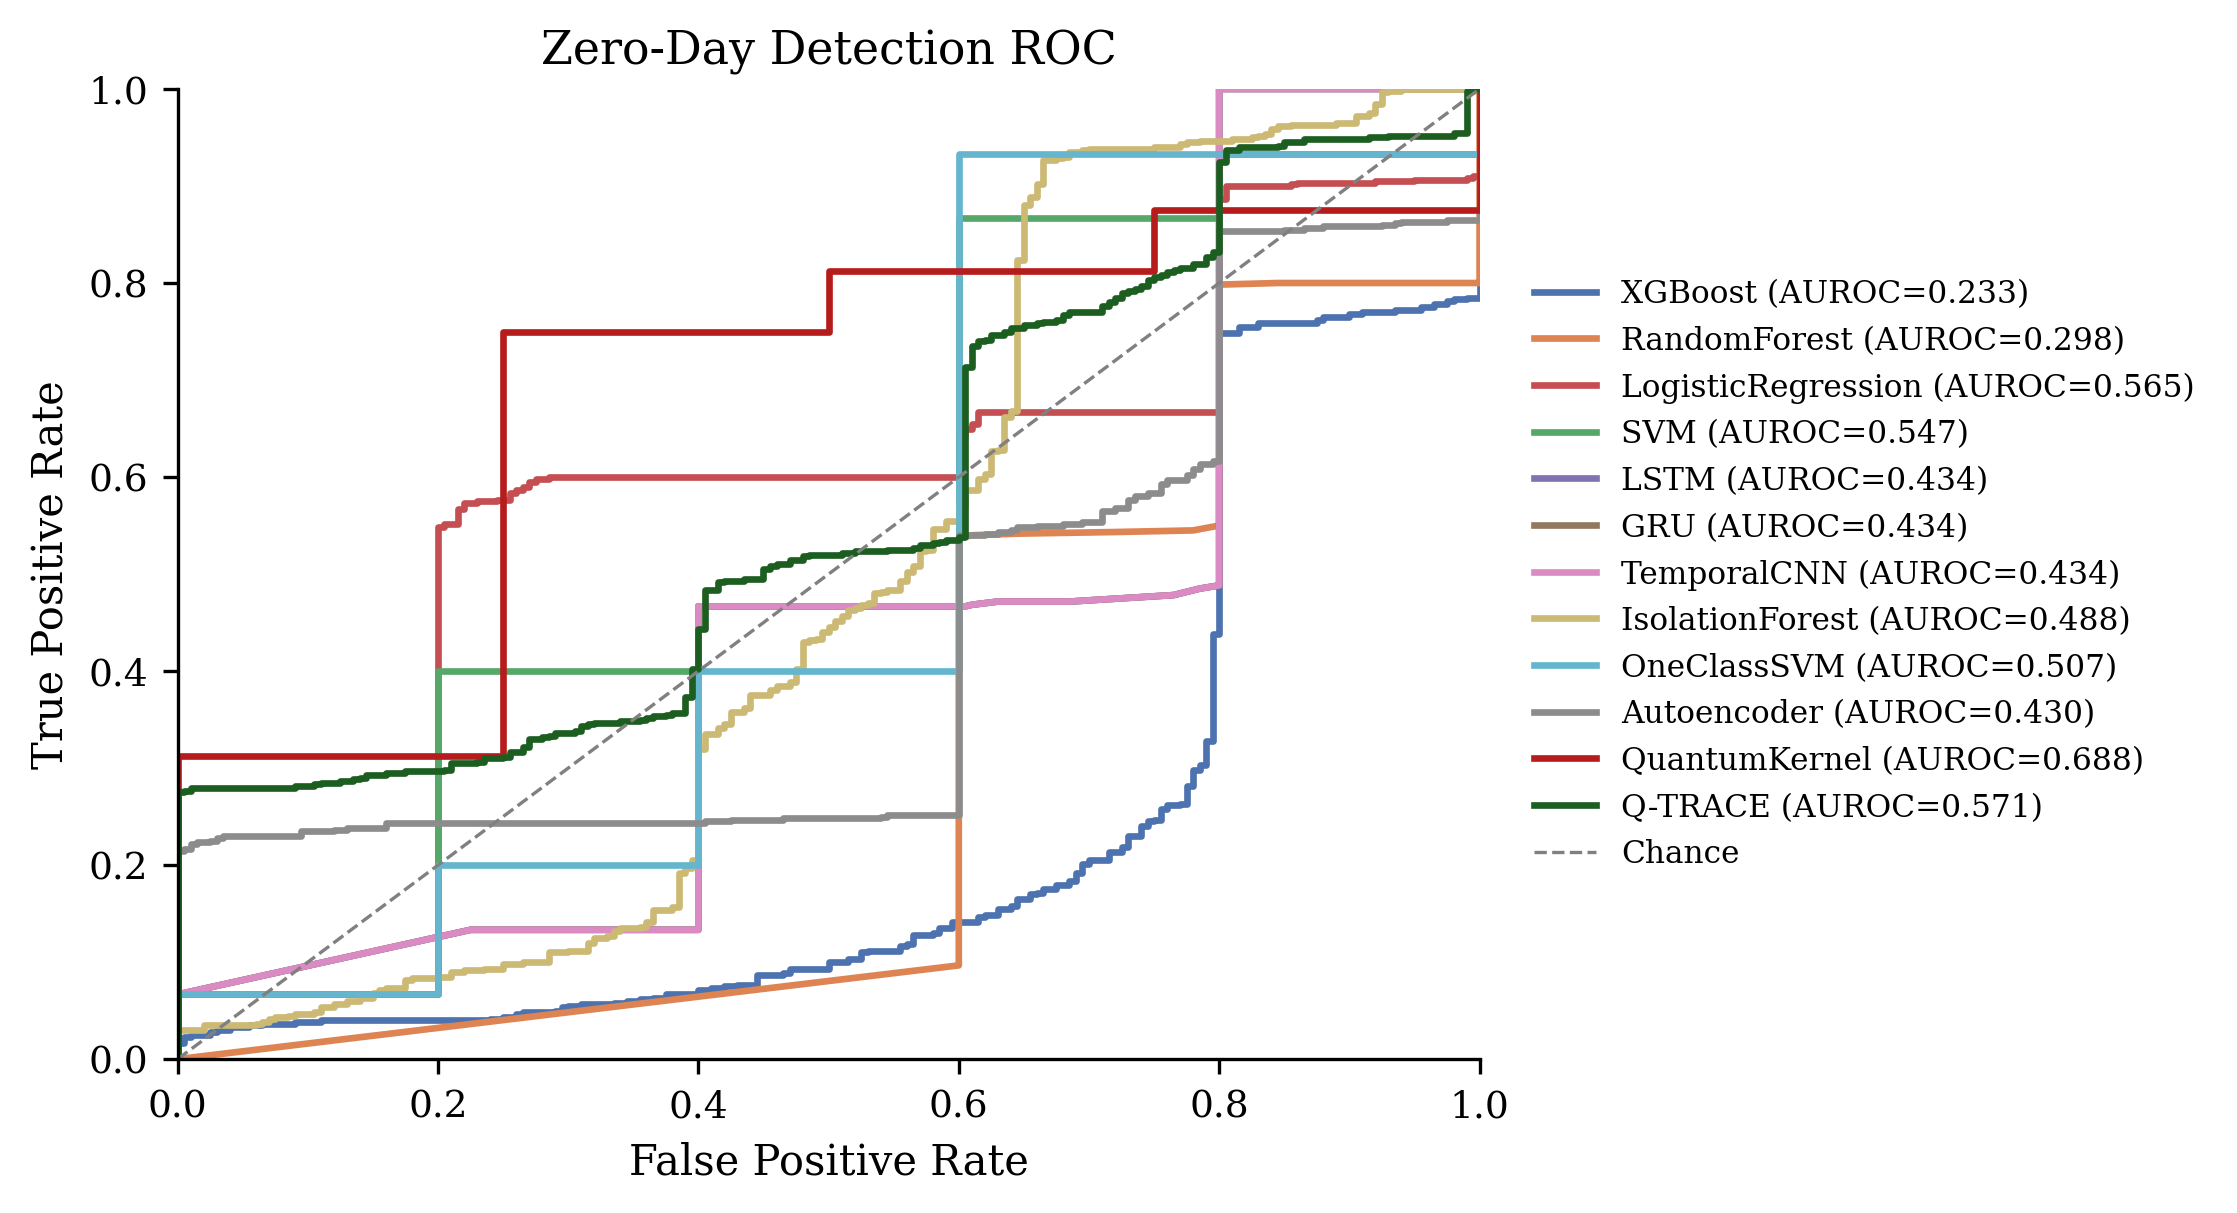

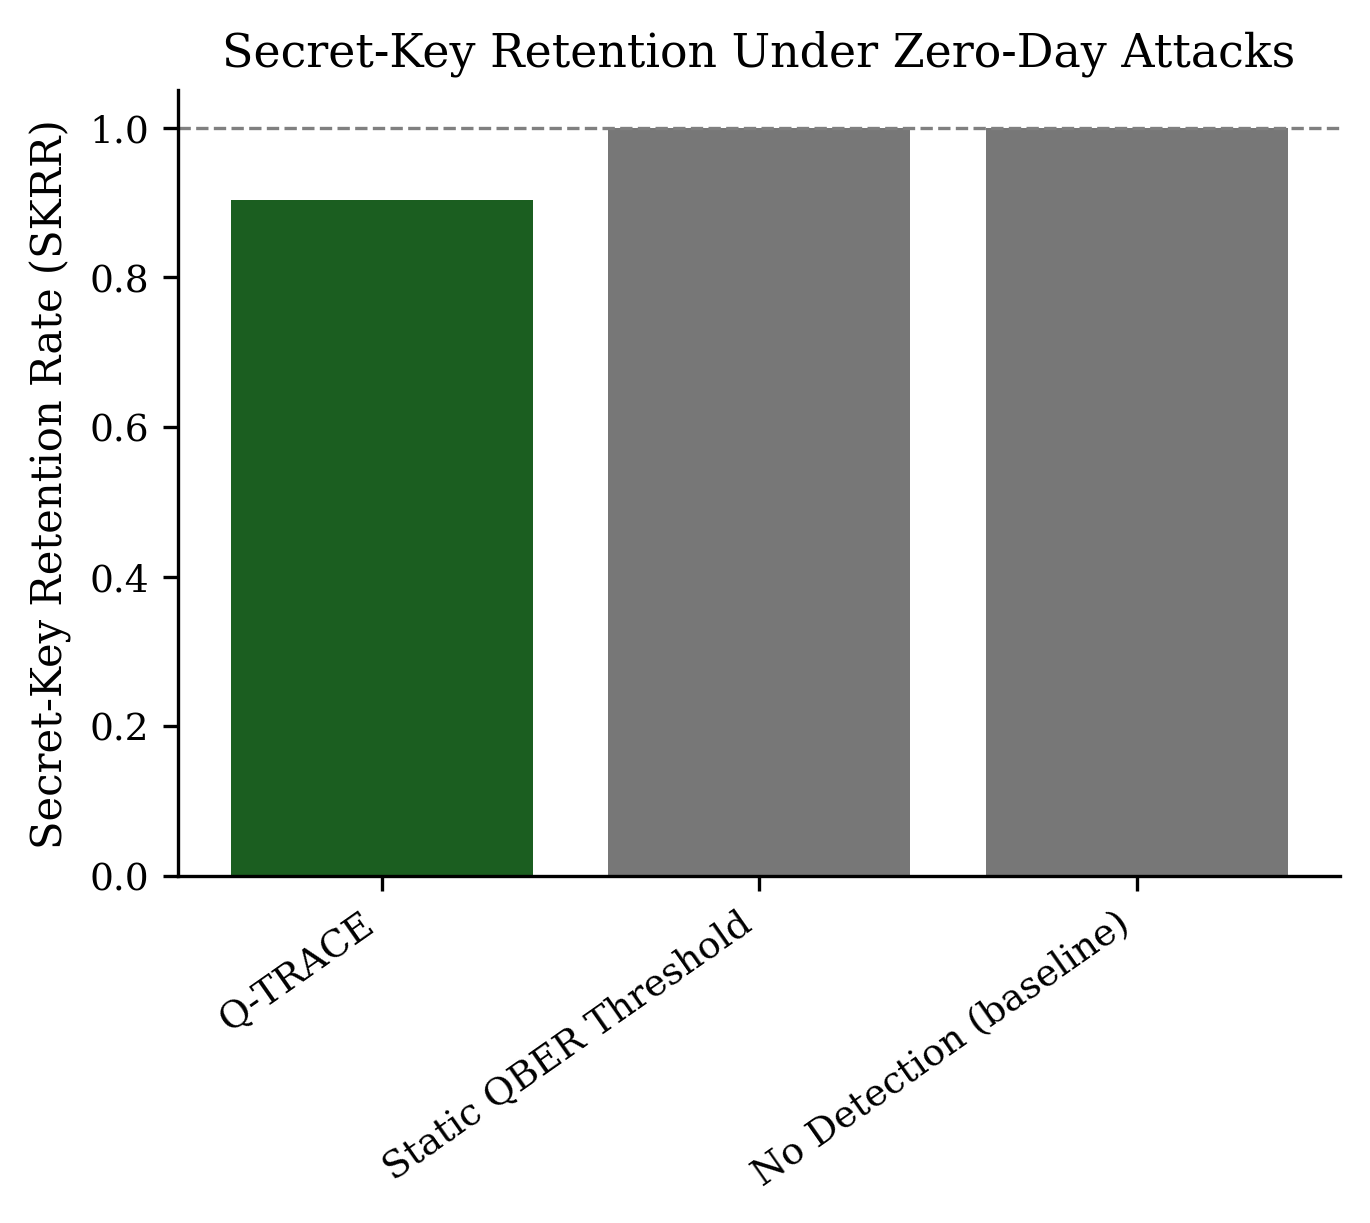

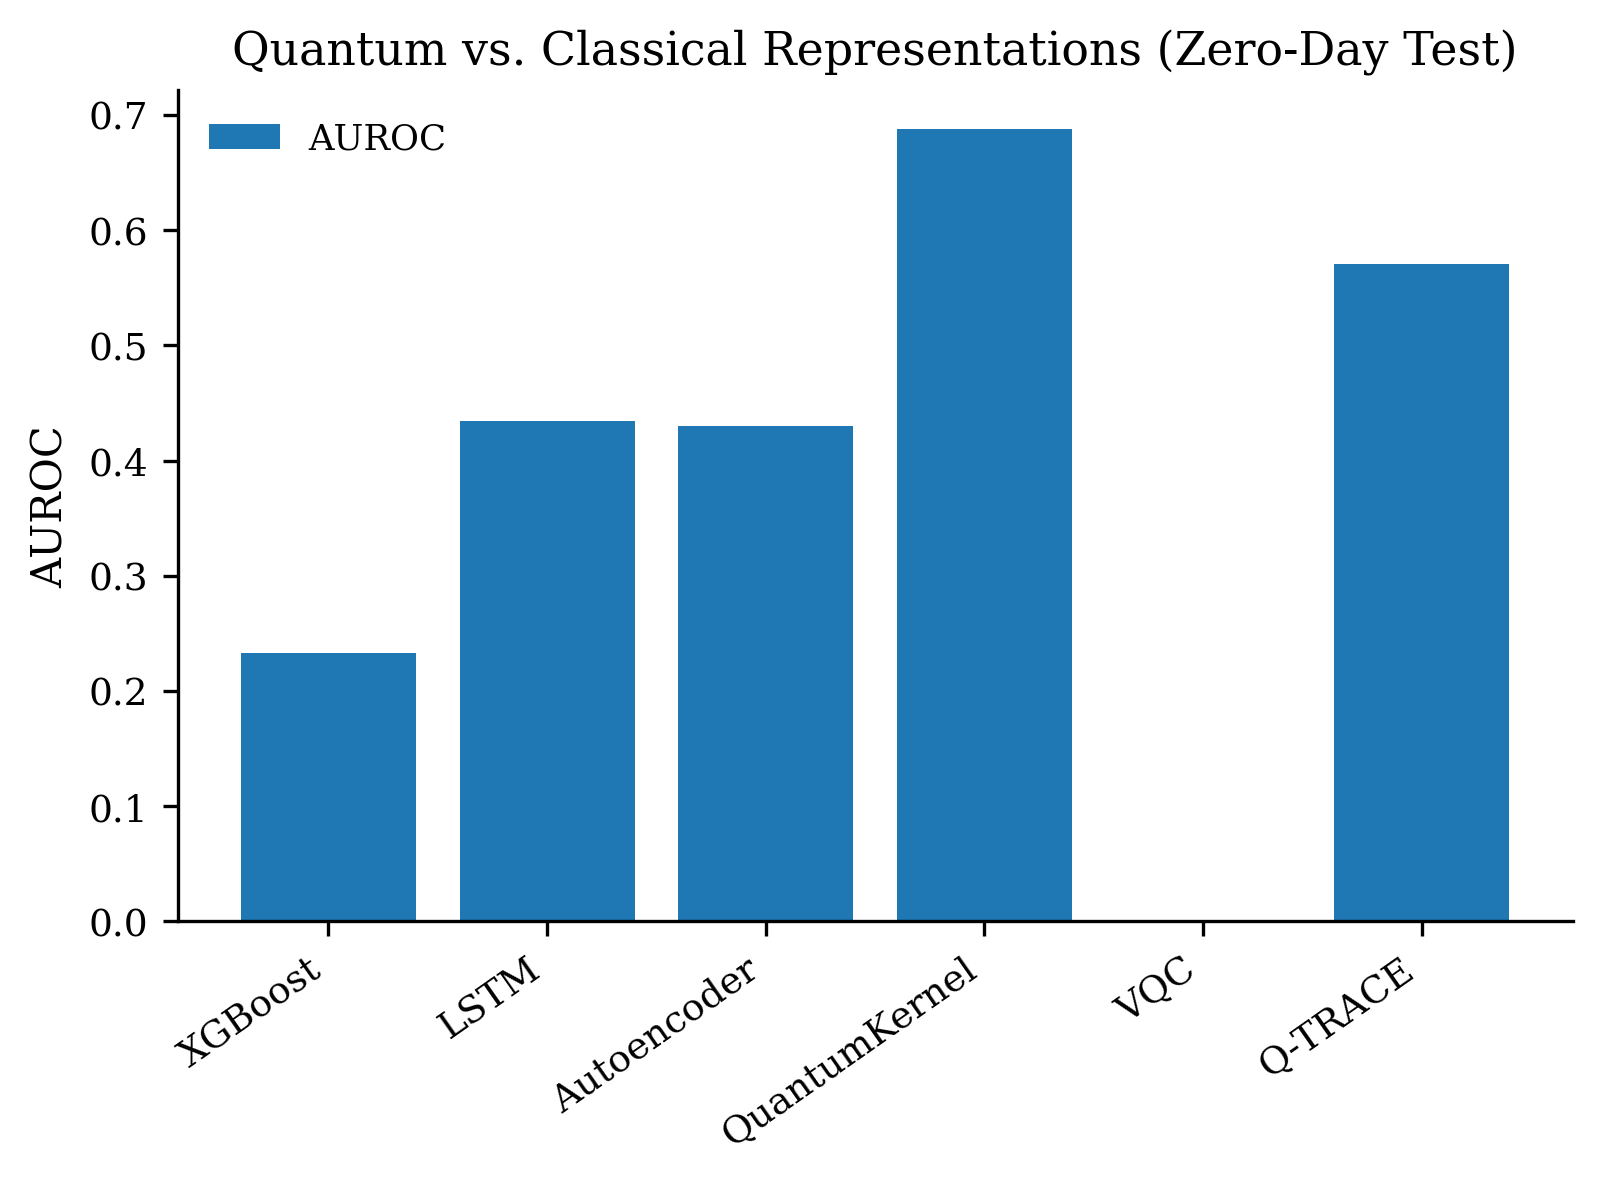

In [7]:
from IPython.display import Image, display
display(Image(filename='../figures/fig5_roc_zeroday.png'))
display(Image(filename='../figures/fig7_skrr.png'))
display(Image(filename='../figures/fig8_quantum_vs_classical.png'))

## 6. Next steps

- Scale up `--runs-per-class` / `--windows-per-run` in Step 3 for publication-scale results.
- Run `python -m evaluation.run_sweep_experiment` for the channel-loss x detector-efficiency zero-day recall heatmap (Figure 6).
- Run `python -m evaluation.run_adversarial_evasion --attack pns` for the adversarial-evasion stress test (Section 24).
- See `quantum/ibm_runtime_job.py` and the README's "Running on real IBM Quantum hardware" section to execute the quantum kernel / VQC inference on `ibm_marrakesh`.